# Price trend: linear-regression baseline
**Problem:** How well does a straight-line trend explain a fund's price? This gives a baseline for more complex forecasting models.
**Approach:** Convert dates to ordinal numbers, hold out the last 100 trading days, fit scikit-learn `LinearRegression` on the rest, then report MSE / R² on the hold-out and plot the prediction against the actual prices.
**Data:** Public Yahoo Finance history for `VGRO.TO`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import yfinance as yf

In [2]:
ticker = "VGRO.TO"
stock = yf.Ticker(ticker)
stockHistory = stock.history(period="max")

## Prepare features: ordinal date → close price

In [3]:
stockHistory.index = stockHistory.index.map(dt.datetime.toordinal)

x0 = stockHistory.index
y0 = stockHistory['Close']

In [4]:
x = np.array([x0]).reshape(-1, 1)
y = np.array([y0]).reshape(-1, 1)

## Hold out the last 100 days, fit, evaluate

In [5]:
xTrain = x[:(len(x)-100)]
xTest = x[(len(x)-100):]

yTrain = y[:(len(x)-100)]
yTest = y[(len(x)-100):]

In [6]:
linearRegressor = LinearRegression()

In [7]:
linearRegressor.fit(xTrain, yTrain)

LinearRegression()

In [8]:
yPrediction = linearRegressor.predict(xTest)

In [9]:
linearRegressor.coef_

array([[0.00700918]])

In [10]:
mean_squared_error(yTest, yPrediction)

60.452389485573285

In [11]:
r2_score(yTest, yPrediction)

-105.12820137523458

## Visualise the fit

In [12]:
stockHistory.index = stockHistory.index.map(dt.datetime.fromordinal)

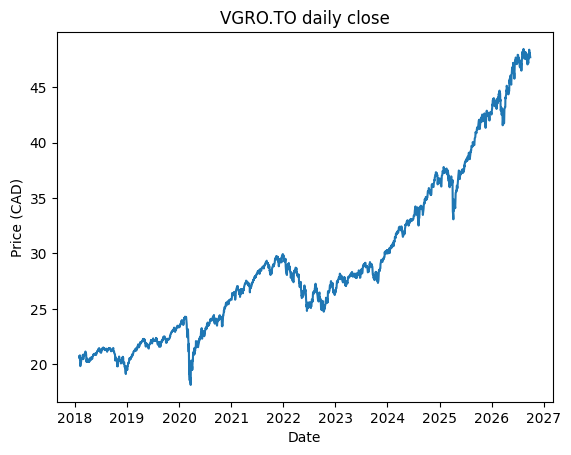

In [13]:
plt.plot(stockHistory.index, stockHistory['Close'])
plt.title(f'{ticker} daily close')
plt.xlabel('Date')
plt.ylabel('Price (CAD)');

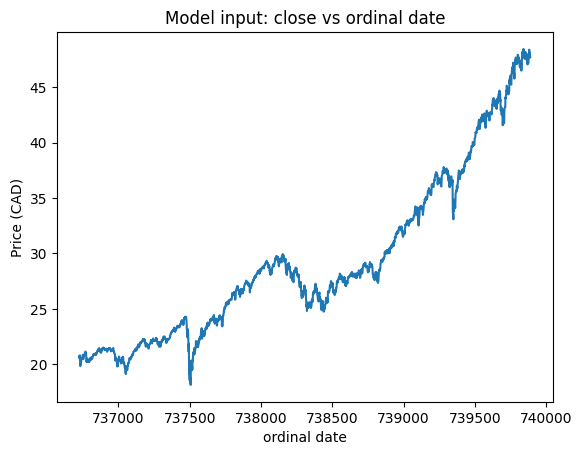

In [14]:
plt.plot(x, y)
plt.title('Model input: close vs ordinal date')
plt.xlabel('ordinal date')
plt.ylabel('Price (CAD)');

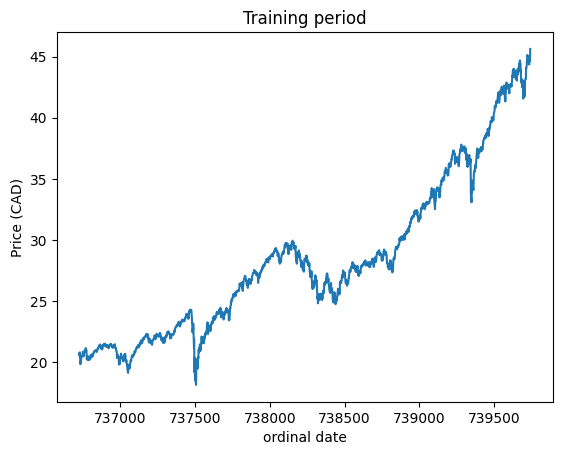

In [15]:
plt.plot(xTrain, yTrain)
plt.title('Training period')
plt.xlabel('ordinal date')
plt.ylabel('Price (CAD)');

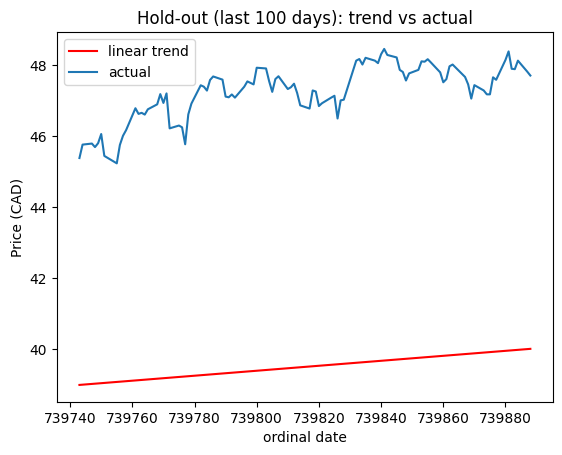

In [16]:
plt.plot(xTest, yPrediction, 'r-', label='linear trend')
plt.plot(xTest, yTest, label='actual')
plt.title('Hold-out (last 100 days): trend vs actual')
plt.xlabel('ordinal date')
plt.ylabel('Price (CAD)')
plt.legend();